## Data Processing in Python Final Project

### Authors: Matyáš Tvrz, Jonathan Eugenio Gaeta

### To Do List:

1) download data from bezrealitky.cz - DONE and reality.idnes.cz, and from sreality.cz on other cities - DONE
2) create heatmap based on longitude and latitude - DONE
3) add property popups to map - DONE
4) download info on airbnb prices
5) conduct a simple analysis of rental price determinants

In [18]:
# import packages

import json
import pandas as pd
import os
import requests 
import pandas as pd 
import time
import re 
import random 
import folium
from folium.plugins import HeatMap, MarkerCluster, GroupedLayerControl
import math
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### sreality.cz dataset

In [2]:
# get sreality df from last request
df_sreality = pd.read_json("df_sreality.json")
df_sreality = pd.DataFrame(df_sreality)

In [3]:
# or get newest sreality df, takes about 6 minutes
from function_scripts import request_sreality_all
df_sreality = request_sreality_all() 
df_sreality.to_json("df_sreality.json", orient="records")

Region 1: 10 pages
Region 2: 11 pages
Region 3: 8 pages
Region 4: 21 pages
Region 5: 6 pages
Region 6: 7 pages
Region 7: 5 pages
Region 8: 12 pages
Region 9: 8 pages
Region 10: 74 pages
Region 11: 14 pages
Region 12: 26 pages
Region 13: 6 pages
Region 14: 27 pages


In [4]:
# get square meters (area) and flat type from name
from function_scripts import name_to_area
df_sreality['area'] = df_sreality.name.apply(name_to_area)
df_sreality['flat_type'] = df_sreality.name.apply(lambda x: x.split()[2])

# get link to listing and thumbnail image
from function_scripts import get_link_and_image
df_sreality = get_link_and_image(df_sreality)

display(df_sreality)

,labelsReleased,has_panorama,labels,is_auction,labelsAll,seo,exclusively_at_rk,category,has_floor_plan,_embedded,...,_links,rus,name,region_tip,gps,has_matterport_url,area,flat_type,url,image
0,"[[], []]",0,[],False,"[[new_building, personal, brick], [kindergarte...","{'category_main_cb': 1, 'category_sub_cb': 5, ...",0,1,0,"{'favourite': {'is_favourite': False, '_links'...",...,{'dynamicDown': [{'href': 'https://d18-a.sdn.c...,False,Pronájem bytu 2+1 63 m²,0,"{'lat': 48.94208868956875, 'lon': 14.547272310...",False,63,2+1,https://www.sreality.cz/detail/pronajem/byt/2+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/kcHp2YdDt...
1,"[[], []]",0,[],False,"[[personal, brick], [tavern, small_shop, vet, ...","{'category_main_cb': 1, 'category_sub_cb': 3, ...",0,1,0,"{'favourite': {'is_favourite': False, '_links'...",...,{'dynamicDown': [{'href': 'https://d18-a.sdn.c...,False,Pronájem bytu 1+1 29 m²,0,"{'lat': 48.97955668956875, 'lon': 14.472409310...",False,29,1+1,https://www.sreality.cz/detail/pronajem/byt/1+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...
2,"[[], []]",0,[],False,"[[personal, after_reconstruction, brick], [sma...","{'category_main_cb': 1, 'category_sub_cb': 6, ...",0,1,0,"{'favourite': {'is_favourite': False, '_links'...",...,{'dynamicDown': [{'href': 'https://d18-a.sdn.c...,False,Pronájem bytu 3+kk 44 m²,0,"{'lat': 49.41306668956875, 'lon': 14.652451310...",False,44,3+kk,https://www.sreality.cz/detail/pronajem/byt/3+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...
3,"[[], []]",0,[],False,"[[personal, terrace, brick, elevator, parking_...","{'category_main_cb': 1, 'category_sub_cb': 4, ...",1,1,0,"{'favourite': {'is_favourite': False, '_links'...",...,{'dynamicDown': [{'href': 'https://d18-a.sdn.c...,False,Pronájem bytu 2+kk 37 m²,0,"{'lat': 48.96456468956875, 'lon': 14.473393310...",False,37,2+kk,https://www.sreality.cz/detail/pronajem/byt/2+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...
4,"[[], []]",0,[],False,"[[personal, brick, cellar, partly_furnished], ...","{'category_main_cb': 1, 'category_sub_cb': 6, ...",0,1,0,"{'favourite': {'is_favourite': False, '_links'...",...,{'dynamicDown': [{'href': 'https://d18-a.sdn.c...,False,Pronájem bytu 3+kk 44 m²,0,"{'lat': 48.95995268956875, 'lon': 14.480598310...",False,44,3+kk,https://www.sreality.cz/detail/pronajem/byt/3+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13815,"[[], []]",0,[],False,"[[personal, parking_lots, furnished], [small_s...","{'category_main_cb': 1, 'category_sub_cb': 47,...",0,1,1,"{'favourite': {'is_favourite': False, '_links'...",...,{'dynamicDown': [{'href': 'https://d18-a.sdn.c...,False,Pronájem pokoje 9 m²,0,"{'lat': 49.14837968956875, 'lon': 16.630737310...",False,9,9,https://www.sreality.cz/detail/pronajem/byt/9/...,https://d18-a.sdn.cz/d_18/c_img_p8_A/kBfrbpoeN...
13816,"[[partly_furnished], []]",0,[Částečně vybavený],False,"[[personal, brick, partly_furnished], [tavern,...","{'category_main_cb': 1, 'category_sub_cb': 4, ...",0,1,0,"{'favourite': {'is_favourite': False, '_links'...",...,{'dynamicDown': [{'href': 'https://d18-a.sdn.c...,False,Pronájem bytu 2+kk 41 m²,0,"{'lat': 48.77458968956875, 'lon': 16.207683310...",False,41,2+kk,https://www.sreality.cz/detail/pronajem/byt/2+...,https://d18-a.sdn.cz/d_18/c_img_oa_B/nsLxLojIr...
13817,"[[terrace, cellar, elevator], []]",0,"[Terasa, Sklep, Výtah]",False,"[[new_building, personal, terrace, cellar, ele...","{'category_main_cb': 1, 'category_sub_cb': 6, ...",0,1,1,"{'favourite': {'is_favourite': False, '_links'...",...,{'dynamicDown': [{'href': 'https://d18-a.sdn.c...,False,Pronájem bytu 3+kk 54 m² (Mezonet),0,"{'lat': 49.18086968956875, 'lon': 16.618877310...",False,54,3+kk,https://www.sreality.cz/detail/pronajem/byt/3+...,https://d18-a.sdn.cz/d_18/c_img_m1_A/nPxnslC6J...
13818,"[[cellar], []]",0,[Sklep],False,"[[personal, brick, cellar, parking_lots], [tav...","{'category_main_cb': 1, 'c

In [5]:
# clean sreality dataset
df_sreality_clean = df_sreality[['locality', 'price', 'flat_type','area','gps','hash_id', 'url','image']].copy()

# get latitude and logitude, manually adjusted based on results
df_sreality_clean[['lat', 'lon']] = df_sreality_clean.gps.apply(lambda x: pd.Series({'lat': x['lat']+ 0.008, 'lon': x['lon']-0.008}))
df_sreality_clean = df_sreality_clean.drop(columns = ["gps", "hash_id"])

display(df_sreality_clean)


,locality,price,flat_type,area,url,image,lat,lon
0,"Srubec, okres České Budějovice",10000,2+1,63,https://www.sreality.cz/detail/pronajem/byt/2+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/kcHp2YdDt...,48.950089,14.539272
1,"České Budějovice - České Budějovice 3, okres Č...",4000,1+1,29,https://www.sreality.cz/detail/pronajem/byt/1+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...,48.987557,14.464409
2,Tábor,9000,3+kk,44,https://www.sreality.cz/detail/pronajem/byt/3+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...,49.421067,14.644451
3,"České Budějovice - České Budějovice 2, okres Č...",10000,2+kk,37,https://www.sreality.cz/detail/pronajem/byt/2+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...,48.972565,14.465393
4,"České Budějovice - České Budějovice 7, okres Č...",8000,3+kk,44,https://www.sreality.cz/detail/pronajem/byt/3+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...,48.967953,14.472598
...,...,...,...,...,...,...,...,...
13815,"Brno - Dolní Heršpice, okres Brno-město",3000,9,9,https://www.sreality.cz/detail/pronajem/byt/9/...,https://d18-a.sdn.cz/d_18/c_img_p8_A/kBfrbpoeN...,49.156380,16.622737
13816,"Slup, okres Znojmo",6000,2+kk,41,https://www.sreality.cz/detail/pronajem/byt/2+...,https://d18-a.sdn.cz/d_18/c_img_oa_B/nsLxLojIr...,48.782590,16.199683
13817,"Brno - Trnitá, okres Brno-město",20000,3+kk,54,https://www.sreality.cz/detail/pronajem/byt/3+...,https://d18-a.sdn.cz/d_18/c_img_m1_A/nPxnslC6J...,49.188870,16.610877
13818,"Lipovec, okres Blansko",5000,1+1,20,https://www.sreality.cz/detail/pronajem/byt/1+...,https://d18-a.sdn.cz/d_18/c_img_QO_K0/nRFBBeM....,49.387410,16.803041


### bezrealitky.cz dataset

In [6]:
# get bezrealitky df from last request
df_bezrealitky = pd.read_json("df_bezrealitky.json")
df_bezrealitky = pd.DataFrame(df_bezrealitky)

In [7]:
# or get newest bezrealitky df, takes about 10 minutes
from function_scripts import request_bezrealitky
bezrealitky_url = "https://www.bezrealitky.cz/vyhledat?estateType=BYT&location=exact&offerType=PRONAJEM&osm_value=%C4%8Cesko&regionOsmIds=R51684&currency=CZK"
df_bezrealitky = request_bezrealitky(bezrealitky_url, 171)
df_bezrealitky.to_json("df_bezrealitky.json", orient="records")

Fetching: Page 1...
Found 15 listings on page 1.
Fetching: Page 2...
Found 15 listings on page 2.
Fetching: Page 3...
Found 15 listings on page 3.
Fetching: Page 4...
Found 15 listings on page 4.
Fetching: Page 5...
Found 15 listings on page 5.
Fetching: Page 6...
Found 15 listings on page 6.
Fetching: Page 7...
Found 15 listings on page 7.
Fetching: Page 8...
Found 15 listings on page 8.
Fetching: Page 9...
Found 15 listings on page 9.
Fetching: Page 10...
Found 15 listings on page 10.
Fetching: Page 11...
Found 15 listings on page 11.
Fetching: Page 12...
Found 15 listings on page 12.
Fetching: Page 13...
Found 15 listings on page 13.
Fetching: Page 14...
Found 15 listings on page 14.
Fetching: Page 15...
Found 15 listings on page 15.
Fetching: Page 16...
Found 15 listings on page 16.
Fetching: Page 17...
Found 15 listings on page 17.
Fetching: Page 18...
Found 15 listings on page 18.
Fetching: Page 19...
Found 15 listings on page 19.
Fetching: Page 20...
Found 15 listings on page 20

In [8]:
# convert flat_type to standard nomenclature
mapping = {
    'DISP_1_KK': '1+kk',
    'DISP_2_KK': '2+kk',
    'DISP_3_KK': '3+kk',
    'DISP_4_KK': '4+kk',
    'DISP_1_1': '1+1',
    'DISP_2_1': '2+1',
    'DISP_3_1': '3+1',
    'DISP_4_1': '4+1',
    'DISP_5_1': '5+1',
    'DISP_7_1': '7+1',
    'GARSONIERA': '1+kk',
    'OSTATNI': 'atypické',
    'UNDEFINED': 'atypické',
}

df_bezrealitky['flat_type'] = df_bezrealitky['flat_type'].map(mapping)
df_bezrealitky_clean = df_bezrealitky

display(df_bezrealitky_clean)

,locality,price,flat_type,area,url,image,lat,lon
0,"Kolmanova, Praha - Modřany",26000,2+kk,51,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,49.999748,14.405154
1,"Topolová, Praha - Záběhlice",17000,1+kk,31,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,50.056365,14.508175
2,"Hodkovická, Praha - Kamýk",25000,2+kk,47,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,50.021895,14.439922
3,"Cejl, Brno - Zábrdovice, Jihomoravský kraj",17990,1+kk,28,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,49.199300,16.624068
4,"Běhounská, Brno - Město Brno, Jihomoravský kraj",6695,3+1,55,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,49.195902,16.609039
...,...,...,...,...,...,...,...,...
2557,"Breslauer Str.20, , Země Sársko",189900,3+1,90,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,49.230550,7.047600
2558,"Herzog-Bernd-Str. 2-4, , Dolní Sasko",7,atypické,107,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,52.986320,9.857220
2559,", Severní Porýní-Vestfálsko",540000,atypické,250,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,50.796190,6.156320
2560,"Neckartenzlinger Str. 5A, , Bádensko-Württembe...",1250,4+1,123,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,48.573080,9.262420


### Pooling datasets

In [9]:
df_all = pd.concat([df_sreality_clean, df_bezrealitky_clean], ignore_index=True)

display(df_all)

,locality,price,flat_type,area,url,image,lat,lon
0,"Srubec, okres České Budějovice",10000,2+1,63,https://www.sreality.cz/detail/pronajem/byt/2+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/kcHp2YdDt...,48.950089,14.539272
1,"České Budějovice - České Budějovice 3, okres Č...",4000,1+1,29,https://www.sreality.cz/detail/pronajem/byt/1+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...,48.987557,14.464409
2,Tábor,9000,3+kk,44,https://www.sreality.cz/detail/pronajem/byt/3+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...,49.421067,14.644451
3,"České Budějovice - České Budějovice 2, okres Č...",10000,2+kk,37,https://www.sreality.cz/detail/pronajem/byt/2+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...,48.972565,14.465393
4,"České Budějovice - České Budějovice 7, okres Č...",8000,3+kk,44,https://www.sreality.cz/detail/pronajem/byt/3+...,https://d18-a.sdn.cz/d_18/c_img_qB_C/nCTUX1iX5...,48.967953,14.472598
...,...,...,...,...,...,...,...,...
16377,"Breslauer Str.20, , Země Sársko",189900,3+1,90,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,49.230550,7.047600
16378,"Herzog-Bernd-Str. 2-4, , Dolní Sasko",7,atypické,107,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,52.986320,9.857220
16379,", Severní Porýní-Vestfálsko",540000,atypické,250,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,50.796190,6.156320
16380,"Neckartenzlinger Str. 5A, , Bádensko-Württembe...",1250,4+1,123,https://www.bezrealitky.cz/nemovitosti-byty-do...,https://api.bezrealitky.cz/media/cache/record_...,48.573080,9.262420


In [10]:
df_heatmap = df_all[['lat', 'lon', 'price']].copy()
df_sreality_property = df_sreality_clean[['lat', 'lon', 'price','locality', 'flat_type', 'area', 'url', 'image']].copy()
df_bezrealitky_property = df_bezrealitky_clean[['lat', 'lon', 'price','locality', 'flat_type', 'area', 'url', 'image']].copy()

### Heatmap

In [11]:
# base map, centered on CZ
m = folium.Map(location=(49.75, 15.40), zoom_start = 8)

heat_data = df_heatmap[['lat', 'lon', 'price']].values.tolist()

# heatmap layer
heat_layer = folium.FeatureGroup(name="Heat Map", show=True)

HeatMap(
    heat_data,
    min_opacity=0.4,
    blur=18,
    radius=15
).add_to(heat_layer)

heat_layer.add_to(m)

# realty website indicator
df_sreality_property['source'] = 'Sreality'
df_bezrealitky_property['source'] = 'Bezrealitky'

# sreality property popups layer
sreality_layer = folium.FeatureGroup(
    name="Sreality Properties",
    show=False
)

sreality_cluster = MarkerCluster().add_to(sreality_layer)

# create popups with variables from df_sreality_property
for _, row in df_sreality_property.iterrows():

    popup_html = f"""
    <b>{row['price']:,} CZK</b><br>
    <b>Source:</b> {row['source']}<br>
    {row['locality']}<br>
    {row['flat_type']}<br>
    {row['area']} m²<br><br>
    <img src="{row['image']}" width="200"><br>
    <a href="{row['url']}" target="_blank">Open listing</a>
    """

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        fill=True,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(sreality_cluster)

sreality_layer.add_to(m)

# bezrealitky property popups layer
bezrealitky_layer = folium.FeatureGroup(
    name="Bezrealitky Properties",
    show=False
)

bezrealitky_cluster = MarkerCluster().add_to(bezrealitky_layer)

# create popups with variables from df_bezrealitky_property
for _, row in df_bezrealitky_property.iterrows():

    popup_html = f"""
    <b>{row['price']:,} CZK</b><br>
    <b>Source:</b> {row['source']}<br>
    {row['locality']}<br>
    {row['flat_type']}<br>
    {row['area']} m²<br><br>
    <img src="{row['image']}" width="200"><br>
    <a href="{row['url']}" target="_blank">Open listing</a>
    """

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        fill=True,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(bezrealitky_cluster)

bezrealitky_layer.add_to(m)


# all datasets merged property popups
all_property = pd.concat(
    [df_sreality_property, df_bezrealitky_property],
    ignore_index=True
)

all_layer = folium.FeatureGroup(
    name="All Properties",
    show=True
)

all_cluster = MarkerCluster().add_to(all_layer)

# create popups with variables from merged dataset
for _, row in all_property.iterrows():

    popup_html = f"""
    <b>{row['price']:,} CZK</b><br>
    <b>Source:</b> {row['source']}<br>
    {row['locality']}<br>
    {row['flat_type']}<br>
    {row['area']} m²<br><br>
    <img src="{row['image']}" width="200"><br>
    <a href="{row['url']}" target="_blank">Open listing</a>
    """

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        fill=True,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(all_cluster)

all_layer.add_to(m)

# layer control
folium.LayerControl(collapsed=False).add_to(m)

# grouped layer control
GroupedLayerControl(
    groups={
        "Property Layers": [
            all_layer,
            sreality_layer,
            bezrealitky_layer
        ]
    },
    exclusive_groups=True,
    collapsed=False
).add_to(m)

# save
m.save("heatmap.html")

In [13]:
df_reg = df_all[['price', 'area', 'flat_type', 'locality']].dropna().copy()

# Extract district from locality
df_reg['district'] = df_reg['locality'].str.extract(r'^([^,]+)')

# Drop extreme outliers (top/bottom 1%)
q_low  = df_reg['price'].quantile(0.01)
q_high = df_reg['price'].quantile(0.99)
df_reg = df_reg[(df_reg['price'] > q_low) & (df_reg['price'] < q_high)]

print(df_reg.shape)
df_reg.head()

(16025, 5)


,price,area,flat_type,locality,district
0,10000,63,2+1,"Srubec, okres České Budějovice",Srubec
1,4000,29,1+1,"České Budějovice - České Budějovice 3, okres Č...",České Budějovice - České Budějovice 3
2,9000,44,3+kk,Tábor,Tábor
3,10000,37,2+kk,"České Budějovice - České Budějovice 2, okres Č...",České Budějovice - České Budějovice 2
4,8000,44,3+kk,"České Budějovice - České Budějovice 7, okres Č...",České Budějovice - České Budějovice 7


In [21]:
# Keep only districts with enough observations
min_obs = 10
district_counts = df_reg['district'].value_counts()
df_reg = df_reg[df_reg['district'].isin(district_counts[district_counts >= min_obs].index)]

print(df_reg['district'].value_counts())

district
Praha 3 - Žižkov              269
Praha 5 - Smíchov             261
Praha 2 - Vinohrady           203
Ostrava - Moravská Ostrava    183
Praha 7 - Holešovice          179
                             ... 
Brno - Jundrov                 10
Plzeňská                       10
Boskovice                      10
Závodní                        10
Okružní                        10
Name: count, Length: 303, dtype: int64


In [22]:
# OLS: price ~ area + flat_type + district

model = smf.ols(
    formula='price ~ area + C(flat_type) + C(district)',
    data=df_reg
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     121.9
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:47:05   Log-Likelihood:            -1.0315e+05
No. Observations:               10746   AIC:                         2.070e+05
Df Residuals:                   10399   BIC:                         2.095e+05
Df Model:                         346                                         
Covariance Type:            nonrobust                                         
                                                                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

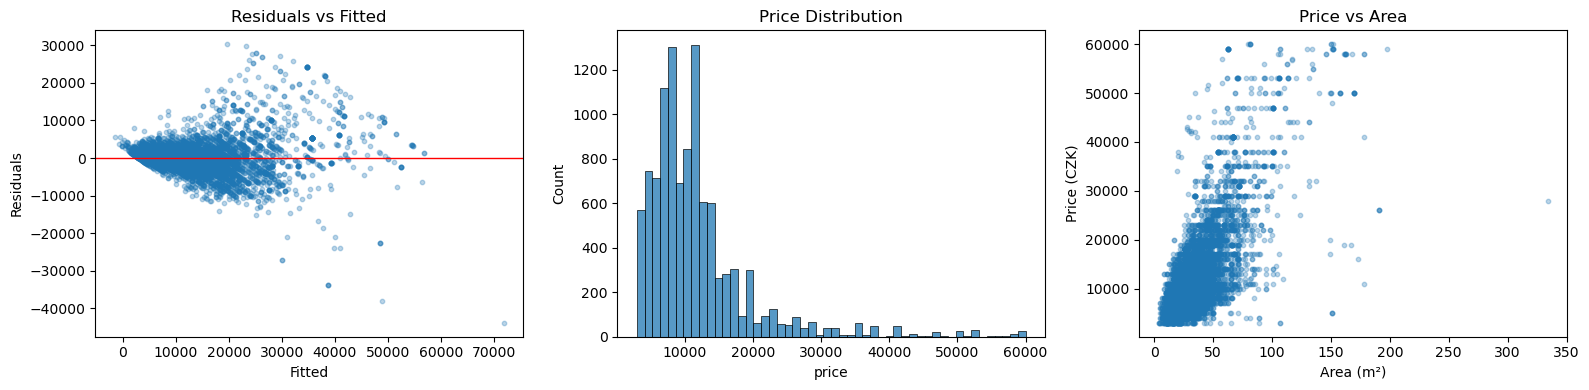

In [23]:
# Key diagnostics

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

#  residuals vs fitted
axes[0].scatter(model.fittedvalues, model.resid, alpha=0.3, s=10)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Fitted'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

#  price distribution
sns.histplot(df_reg['price'], bins=50, ax=axes[1])
axes[1].set_title('Price Distribution')

#  price vs area
axes[2].scatter(df_reg['area'], df_reg['price'], alpha=0.3, s=10)
axes[2].set_xlabel('Area (m²)'); axes[2].set_ylabel('Price (CZK)')
axes[2].set_title('Price vs Area')

plt.tight_layout()
plt.show()

In [24]:
# Log-linear model
df_reg['log_price'] = np.log(df_reg['price'])

model_log = smf.ols(
    formula='log_price ~ area + C(flat_type) + C(district)',
    data=df_reg
).fit()

print(model_log.summary())

# Coefficient interpretation: area coef ≈ % change in price per extra m²
print(f"\nArea coefficient: {model_log.params['area']:.4f}")
print(f"→ Each extra m² is associated with ~{model_log.params['area']*100:.2f}% higher rent")

C:\Users\jonny\AppData\Local\Temp\ipykernel_24272\4212035780.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg['log_price'] = np.log(df_reg['price'])


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     176.3
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:47:07   Log-Likelihood:                 1753.2
No. Observations:               10746   AIC:                            -2812.
Df Residuals:                   10399   BIC:                            -285.5
Df Model:                         346                                         
Covariance Type:            nonrobust                                         
                                                                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

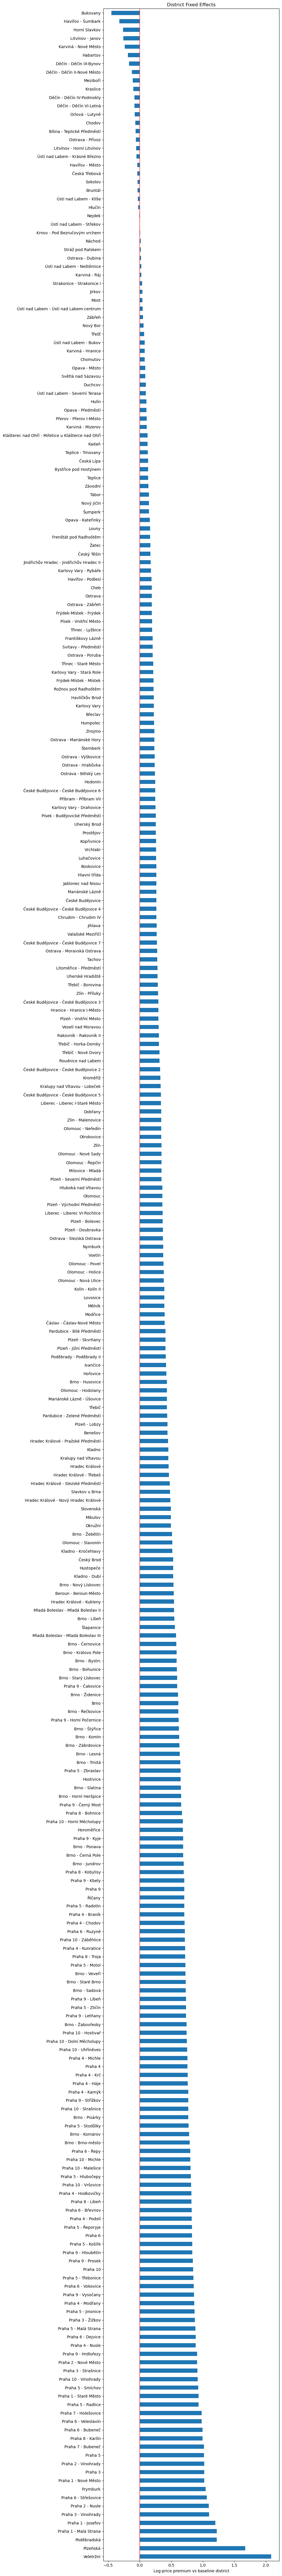

In [25]:
#Quick summary table of district fixed effects
fe = model_log.params.filter(like='C(district)')
fe.index = fe.index.str.replace(r'C\(district\)\[T\.', '', regex=True).str.replace(']', '')
fe_sorted = fe.sort_values(ascending=False)

plt.figure(figsize=(10, max(4, len(fe_sorted)*0.3)))
fe_sorted.plot(kind='barh')
plt.axvline(0, color='red', lw=1)
plt.xlabel('Log-price premium vs baseline district')
plt.title('District Fixed Effects')
plt.tight_layout()
plt.show()